# 02. Promotional Discount Impact & Unit Economics Breakdown

## Executive Summary
This analysis investigates the financial elasticity and unit economics across promotional discount tiers (0% to 20%).

### Key Business Questions
- **Price Dilution:** How much absolute gross cash per unit is sacrificed at higher discount tiers?
- **Volume Elasticity:** Do promotional discount tiers generate enough incremental unit volume to offset the realized cash compression?
- **Margin Sensitivity:** Is percentage margin preserved at the expense of bottom-line dollar profitability?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Styling configuration
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
sns.set_context("talk")
plt.rcParams["figure.figsize"] = (10, 5)

# Load data
df = pd.read_csv("sample_data/data/Ecommerce_Sales_Data_2024_2025.csv")

# Clean Dates
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%y', errors='coerce')
df['COGS'] = df['Sales'] - df['Profit']

print(f"Transactions: {len(df):,} | Active Discount Brackets: {sorted(df['Discount'].unique())}")

Transactions: 5,000 | Active Discount Brackets: [np.int64(0), np.int64(5), np.int64(10), np.int64(15), np.int64(20)]


In [2]:
# 1. Unit Economics & Elasticity Aggregation
discount_summary = df.groupby('Discount').agg(
    Orders=('Order ID', 'nunique'),
    Units_Sold=('Quantity', 'sum'),
    Gross_Revenue=('Sales', 'sum'),
    COGS=('COGS', 'sum'),
    Gross_Profit=('Profit', 'sum')
).reset_index()

# Metric Calculations
discount_summary['Gross_Margin_%'] = discount_summary['Gross_Profit'] / discount_summary['Gross_Revenue']
discount_summary['Realized_Price_per_Unit'] = discount_summary['Gross_Revenue'] / discount_summary['Units_Sold']
discount_summary['COGS_per_Unit'] = discount_summary['COGS'] / discount_summary['Units_Sold']
discount_summary['Profit_per_Unit'] = discount_summary['Gross_Profit'] / discount_summary['Units_Sold']
discount_summary['AOV'] = discount_summary['Gross_Revenue'] / discount_summary['Orders']

# Calculation of Cash Dilution vs. Baseline (0% Discount)
base_profit_unit = discount_summary.loc[discount_summary['Discount'] == 0, 'Profit_per_Unit'].values[0]
discount_summary['Unit_Cash_Dilution_%'] = (discount_summary['Profit_per_Unit'] - base_profit_unit) / base_profit_unit

# Executive Formatted Display Table
display_table = discount_summary.copy()
display_table['Discount Tier'] = display_table['Discount'].map("{}%".format)
display_table['Orders'] = display_table['Orders'].map("{:,}".format)
display_table['Units Sold'] = display_table['Units_Sold'].map("{:,}".format)
display_table['Gross Revenue'] = display_table['Gross_Revenue'].map("${:,.2f}".format)
display_table['Gross Profit'] = display_table['Gross_Profit'].map("${:,.2f}".format)
display_table['Realized Price/Unit'] = display_table['Realized_Price_per_Unit'].map("${:,.2f}".format)
display_table['Profit/Unit'] = display_table['Profit_per_Unit'].map("${:,.2f}".format)
display_table['Gross Margin %'] = display_table['Gross_Margin_%'].map("{:.2%}".format)
display_table['Unit Profit Dilution'] = display_table['Unit_Cash_Dilution_%'].map("{:.2%}".format)

display_table[[
    'Discount Tier', 'Orders', 'Units Sold', 'Gross Revenue',
    'Gross Profit', 'Realized Price/Unit', 'Profit/Unit', 'Gross Margin %', 'Unit Profit Dilution'
]]

,Discount Tier,Orders,Units Sold,Gross Revenue,Gross Profit,Realized Price/Unit,Profit/Unit,Gross Margin %,Unit Profit Dilution
0,0%,998,"2,930","$117,106,034.00","$17,266,608.70","$39,967.93","$5,893.04",14.74%,0.00%
1,5%,978,"3,016","$112,096,122.10","$17,059,182.93","$37,167.15","$5,656.23",15.22%,-4.02%
2,10%,"1,020","3,100","$110,572,965.90","$16,562,542.62","$35,668.70","$5,342.76",14.98%,-9.34%
3,15%,983,"2,885","$97,285,450.35","$14,575,951.61","$33,721.13","$5,052.32",14.98%,-14.27%
4,20%,"1,021","3,032","$96,605,452.00","$14,244,449.05","$31,861.96","$4,698.04",14.74%,-20.28%


## 2. Unit Economics Erosion: Price Realization vs. Realized Cash Margin
Visualizing how discounts compress the cash profit harvested per individual unit sold.

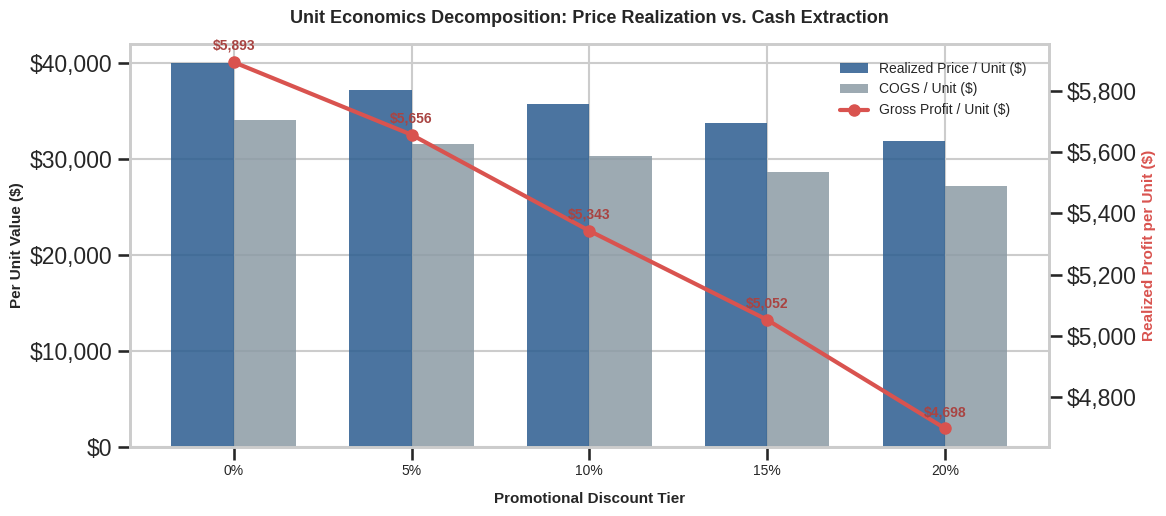

In [3]:
# Visualization: Unit Economics Compression & Cash Drag
fig, ax1 = plt.subplots(figsize=(12, 5.5))

discount_labels = [f"{d}%" for d in discount_summary['Discount']]
x = np.arange(len(discount_labels))
width = 0.35

# Realized Price vs. COGS
rects1 = ax1.bar(x - width/2, discount_summary['Realized_Price_per_Unit'], width, label='Realized Price / Unit ($)', color='#2b5c8f', alpha=0.85)
rects2 = ax1.bar(x + width/2, discount_summary['COGS_per_Unit'], width, label='COGS / Unit ($)', color='#8c9ba5', alpha=0.85)

ax1.set_ylabel('Per Unit Value ($)', fontsize=11, fontweight='bold')
ax1.set_xlabel('Promotional Discount Tier', fontsize=11, fontweight='bold', labelpad=10)
ax1.set_xticks(x)
ax1.set_xticklabels(discount_labels, fontsize=10)
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, p: f"${y:,.0f}"))

# Dual-Axis for Unit Profit Erosion
ax2 = ax1.twinx()
ax2.plot(x, discount_summary['Profit_per_Unit'], color='#d9534f', marker='o', linewidth=3, markersize=8, label='Gross Profit / Unit ($)')
ax2.set_ylabel('Realized Profit per Unit ($)', fontsize=11, color='#d9534f', fontweight='bold')
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, p: f"${y:,.0f}"))
ax2.grid(False)

# Add data labels for Profit per unit
for i, txt in enumerate(discount_summary['Profit_per_Unit']):
    ax2.annotate(f"${txt:,.0f}", (x[i], txt + 40), fontsize=10, ha='center', fontweight='bold', color='#a94442')

plt.title('Unit Economics Decomposition: Price Realization vs. Cash Extraction', fontsize=13, fontweight='bold', pad=15)
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88), fontsize=10)
plt.tight_layout()
plt.show()

## 3. Volume Inelasticity & Cash Dilution Assessment
Evaluating whether incremental sales volumes compensate for the profit per unit drop.

In [4]:
# Volume vs Profit Decay Matrix
decay_matrix = pd.DataFrame({
    "Metric": [
        "Base Unit Cash Generation (0% Tier)",
        "Discounted Unit Cash Generation (20% Tier)",
        "Absolute Profit Sacrificed per Unit",
        "Total Profit Dilution at 20% Tier",
        "Volume Uplift (0% -> 20% Tier)"
    ],
    "Value": [
        f"${discount_summary.loc[discount_summary['Discount']==0, 'Profit_per_Unit'].values[0]:,.2f}",
        f"${discount_summary.loc[discount_summary['Discount']==20, 'Profit_per_Unit'].values[0]:,.2f}",
        f"${(discount_summary.loc[discount_summary['Discount']==0, 'Profit_per_Unit'].values[0] - discount_summary.loc[discount_summary['Discount']==20, 'Profit_per_Unit'].values[0]):,.2f}",
        f"{discount_summary.loc[discount_summary['Discount']==20, 'Unit_Cash_Dilution_%'].values[0]:.2%}",
        f"{(discount_summary.loc[discount_summary['Discount']==20, 'Units_Sold'].values[0] / discount_summary.loc[discount_summary['Discount']==0, 'Units_Sold'].values[0] - 1):.2%}"
    ]
})

decay_matrix

,Metric,Value
0,Base Unit Cash Generation (0% Tier),"$5,893.04"
1,Discounted Unit Cash Generation (20% Tier),"$4,698.04"
2,Absolute Profit Sacrificed per Unit,"$1,195.00"
3,Total Profit Dilution at 20% Tier,-20.28%
4,Volume Uplift (0% -> 20% Tier),3.48%


## Strategic Findings & Policy Recommendations

- **Constant % Margin Illusion:** While the mathematical margin percentage holds steady at **~14.7% - 15.0%**, the absolute dollar profit generated per unit drops by **-20.28%** (from **$5,893.04** at 0% discount down to **$4,698.04** at 20% discount).
- **Inelastic Demand Curve:** Offering a 20% discount only drives a **+3.48%** increase in unit volume (2,930 units vs. 3,032 units), failing to generate the volume needed to offset price destruction.
- **Actionable Takeaway:** Broad promotional discounting creates uncompensated revenue dilution. Promotional caps must be enforced, shifting strategy toward minimum order threshold bundles rather than blanket percentage discounts.